Realizado por:
* Diogo Vasco 2023226969 
* Rodrigo Gonçalves 2023226160

notas: SMOTE no grupo C reduziu metricas

## Imports

In [1]:
import imblearn
import pandas as pd
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt 
import numpy as np 
from sklearn.neural_network import MLPClassifier  
from sklearn.model_selection import cross_val_score  
from sklearn.metrics import precision_score, recall_score, f1_score 
from sklearn.preprocessing import MinMaxScaler, StandardScaler 

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, accuracy_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              precision_score, recall_score, f1_score)

sns.set_theme()

## Data Loading

In [2]:
stressL='sleepStress.csv'
df= pd.read_csv(stressL)

## Exploratory Data Analysis

Before cleaning, we inspect the raw dataset to understand its size, structure, missing values, and the main variable distributions.

### 1. Data Quality Check

In [3]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False))
print("\nDuplicate rows:", df.duplicated().sum())
print("\nNumerical summary:")
display(df.describe().T)
print("\nCategorical summary:")
display(df.describe(include='object').T)
display(df.head())

Shape: (15000, 13)

Data types:
user_id                               int64
age                                   int64
gender                                  str
occupation                              str
daily_screen_time_hours             float64
phone_usage_before_sleep_minutes      int64
sleep_duration_hours                float64
sleep_quality_score                 float64
stress_level                        float64
caffeine_intake_cups                  int64
physical_activity_minutes             int64
notifications_received_per_day        int64
mental_fatigue_score                float64
dtype: object

Missing values:
user_id                             0
age                                 0
gender                              0
occupation                          0
daily_screen_time_hours             0
phone_usage_before_sleep_minutes    0
sleep_duration_hours                0
sleep_quality_score                 0
stress_level                        0
caffeine_intake_cups   

,count,mean,std,min,25%,50%,75%,max
user_id,15000.0,7500.500000,4330.271354,1.0,3750.75,7500.50,11250.25,15000.0
age,15000.0,38.488467,12.007970,18.0,28.00,38.00,49.00,59.0
daily_screen_time_hours,15000.0,5.501528,2.600085,1.0,3.26,5.49,7.76,10.0
phone_usage_before_sleep_minutes,15000.0,59.708933,34.641858,0.0,29.00,60.00,90.00,119.0
sleep_duration_hours,15000.0,6.509683,1.452689,4.0,5.26,6.49,7.79,9.0
sleep_quality_score,15000.0,6.246362,1.713644,1.0,5.00,6.25,7.50,10.0
stress_level,15000.0,6.980247,2.749382,1.0,4.75,7.38,10.00,10.0
caffeine_intake_cups,15000.0,1.998800,1.414590,0.0,1.00,2.00,3.00,4.0
physical_activity_minutes,15000.0,59.157133,34.525705,0.0,29.00,59.00,89.00,119.0
notifications_received_per_day,15000.0,160.890467,80.856902,20.0,92.00,162.00,231.00,299.0



Categorical summary:


/tmp/ipykernel_3485/2379990646.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include='object').T)


,count,unique,top,freq
gender,15000,3,Male,7234
occupation,15000,8,Manager,1962


,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99


### 2. Feature Distributions

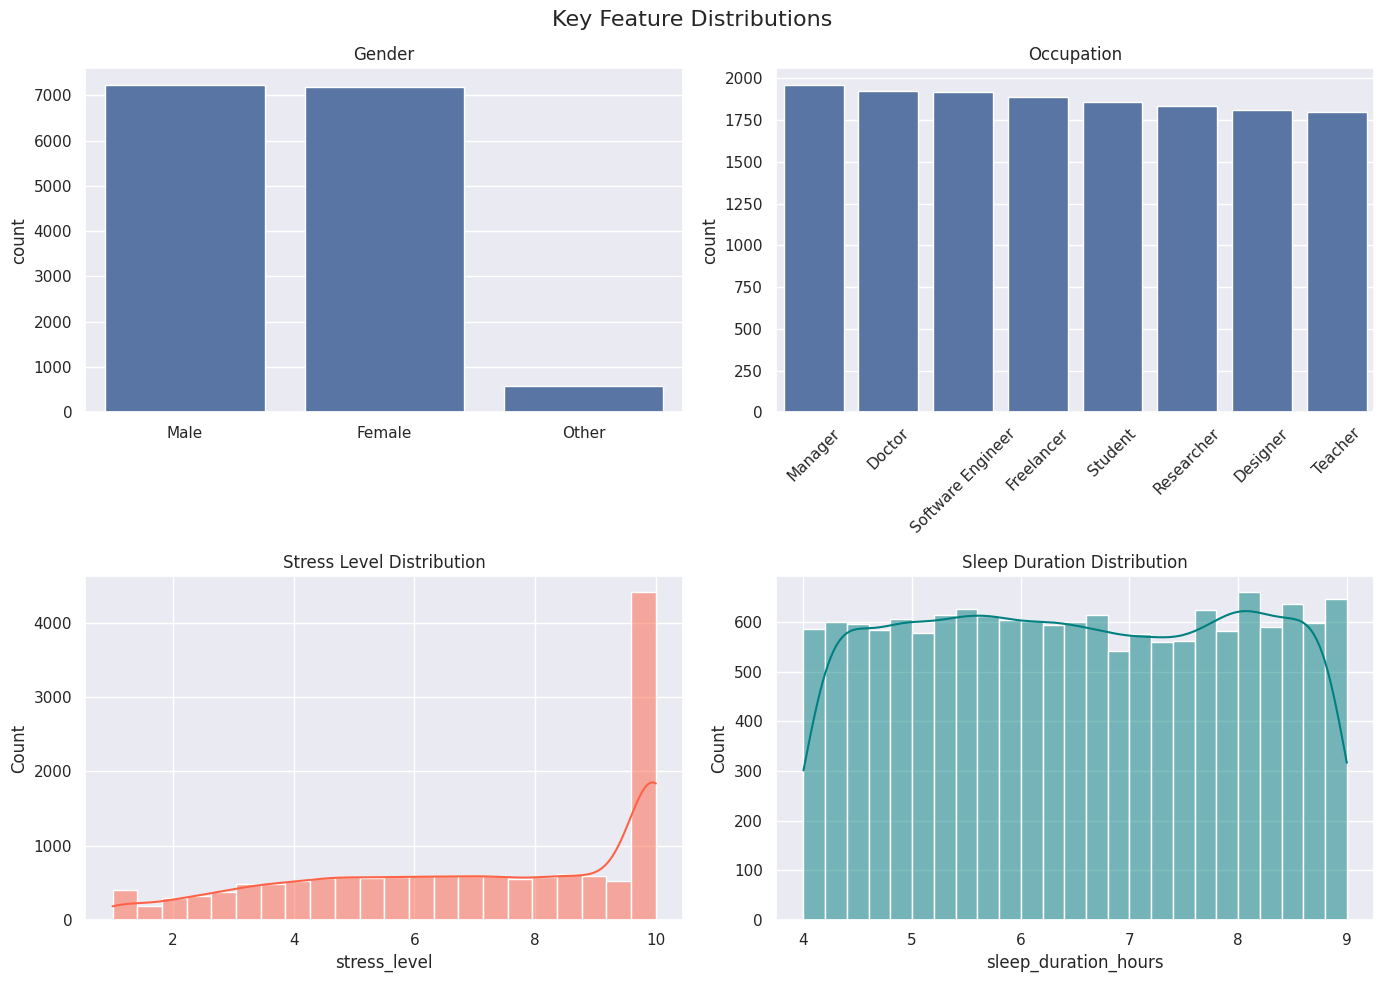

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Key Feature Distributions', fontsize=16)

sns.countplot(data=df, x='gender', order=df['gender'].value_counts().index, ax=axes[0, 0])
axes[0, 0].set_title('Gender')
axes[0, 0].set_xlabel('')

sns.countplot(data=df, x='occupation', order=df['occupation'].value_counts().index, ax=axes[0, 1])
axes[0, 1].set_title('Occupation')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].set_xlabel('')

sns.histplot(df['stress_level'], kde=True, ax=axes[1, 0], color='tomato')
axes[1, 0].set_title('Stress Level Distribution')

sns.histplot(df['sleep_duration_hours'], kde=True, ax=axes[1, 1], color='teal')
axes[1, 1].set_title('Sleep Duration Distribution')

plt.tight_layout()
plt.show()

### 3. Box Plots - Numerical Features

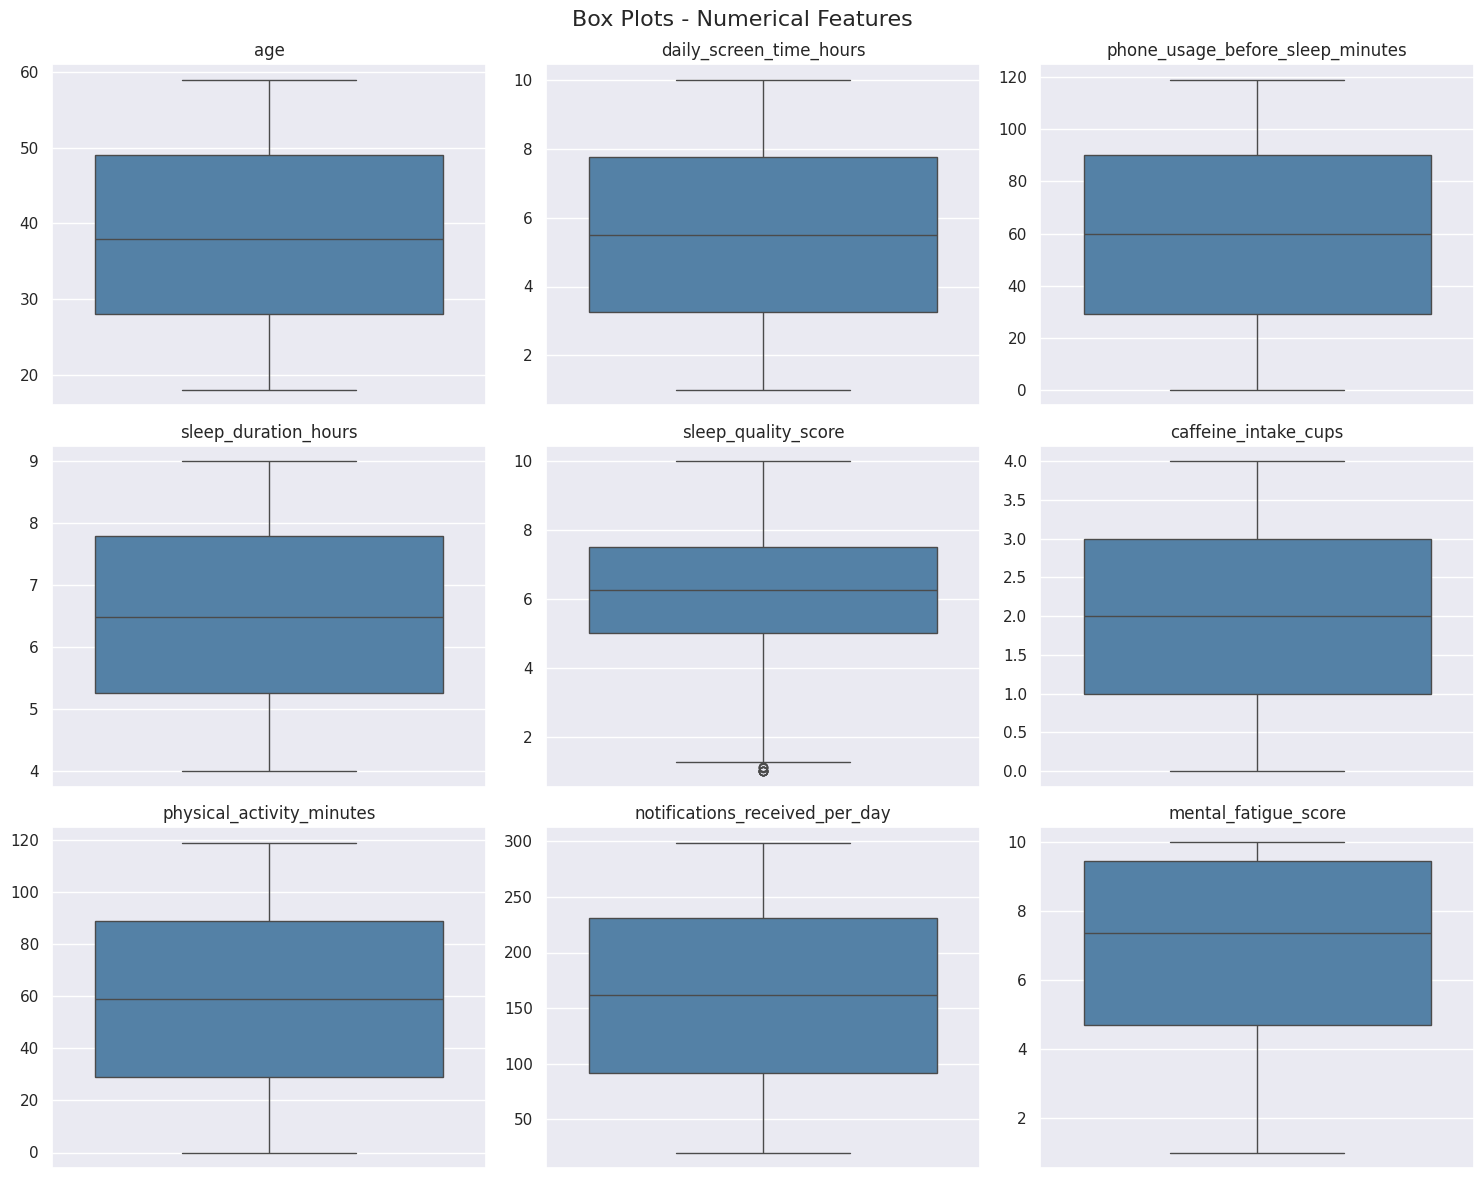

In [5]:
num_cols = [
    'age', 'daily_screen_time_hours', 'phone_usage_before_sleep_minutes',
    'sleep_duration_hours', 'sleep_quality_score', 'caffeine_intake_cups',
    'physical_activity_minutes', 'notifications_received_per_day', 'mental_fatigue_score'
]
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Box Plots - Numerical Features', fontsize=16)
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(y=df[col], ax=ax, color='steelblue')
    ax.set_title(col)
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

### 4. Target Variable & Class Imbalance

`stress_level` is continuous [1, 10]. We discretise it for each scenario using equal-width binning.

/tmp/ipykernel_3485/2430147923.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='viridis')
/tmp/ipykernel_3485/2430147923.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='viridis')
/tmp/ipykernel_3485/2430147923.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='viridis')


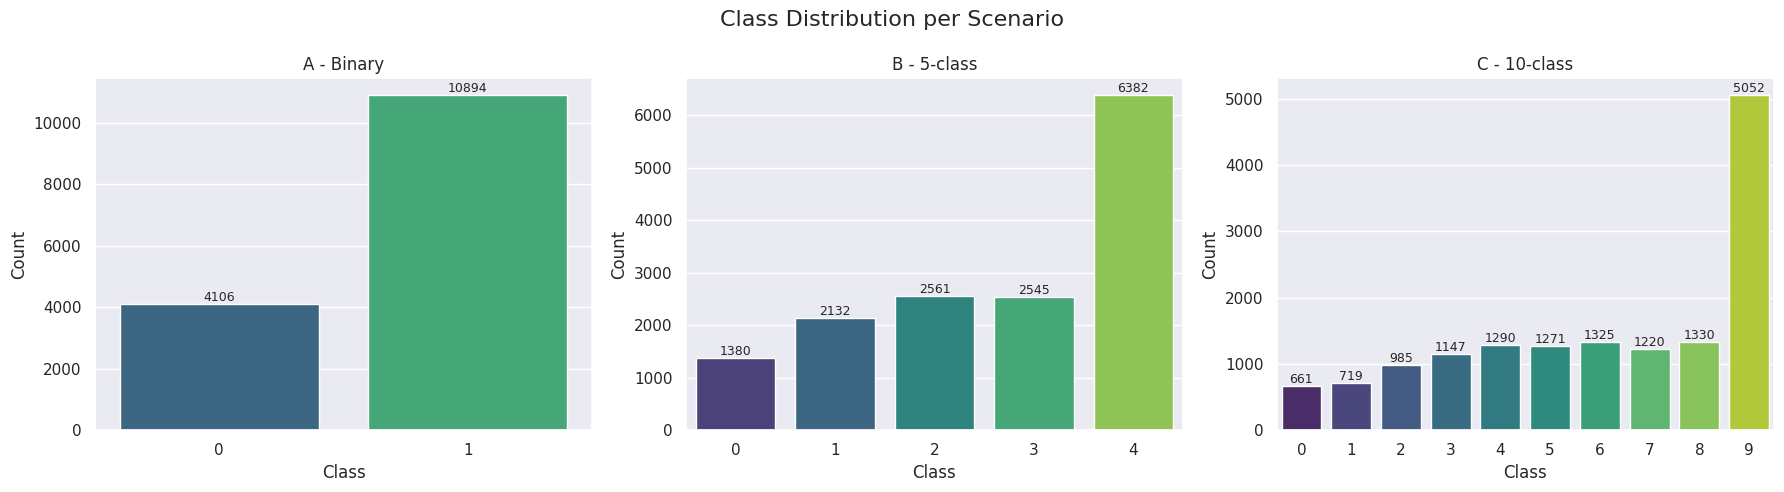

Scenario A: {0: np.int64(4106), 1: np.int64(10894)}
Scenario B: {0: np.int64(1380), 1: np.int64(2132), 2: np.int64(2561), 3: np.int64(2545), 4: np.int64(6382)}
Scenario C: {0: np.int64(661), 1: np.int64(719), 2: np.int64(985), 3: np.int64(1147), 4: np.int64(1290), 5: np.int64(1271), 6: np.int64(1325), 7: np.int64(1220), 8: np.int64(1330), 9: np.int64(5052)}


In [6]:
# Scenario A - binary: [1, 5) = 0 (no stress), [5, 10] = 1 (stress)
df['stress_A'] = (df['stress_level'] >= 5).astype(int)

# Scenario B - 5-class equal-width
df['stress_B'] = pd.cut(df['stress_level'], bins=5, labels=[0, 1, 2, 3, 4]).astype(int)

# Scenario C - 10-class equal-width
df['stress_C'] = pd.cut(df['stress_level'], bins=10, labels=list(range(10))).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Class Distribution per Scenario', fontsize=16)
for ax, col, title in zip(axes,
                           ['stress_A', 'stress_B', 'stress_C'],
                           ['A - Binary', 'B - 5-class', 'C - 10-class']):
    counts = df[col].value_counts().sort_index()
    sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='viridis')
    ax.set_title(title)
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

for col, name in [('stress_A', 'A'), ('stress_B', 'B'), ('stress_C', 'C')]:
    counts = df[col].value_counts().sort_index()
    pct = (counts / len(df) * 100).round(1)
    print(f'Scenario {name}:', dict(zip(counts.index, counts.values)))

### 5. Stress Level vs. Key Features

Scatter plots with regression lines for the four strongest correlates of `stress_level`.

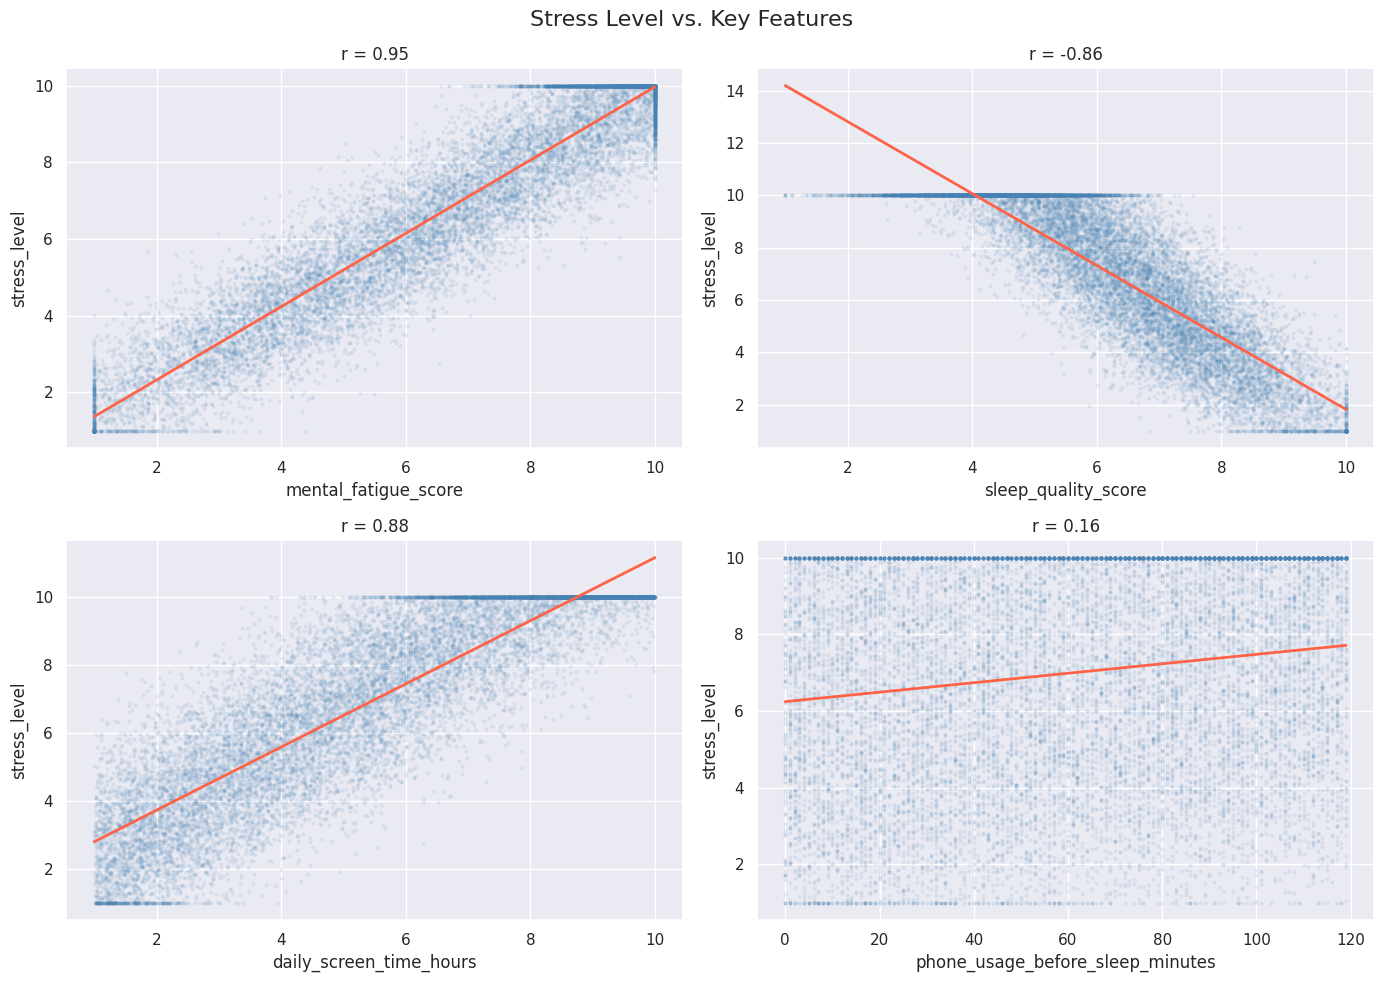

In [7]:
top_features = ['mental_fatigue_score', 'sleep_quality_score', 'daily_screen_time_hours', 'phone_usage_before_sleep_minutes']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Stress Level vs. Key Features', fontsize=16)
for ax, feat in zip(axes.flatten(), top_features):
    ax.scatter(df[feat], df['stress_level'], alpha=0.08, s=4, color='steelblue')
    m, b = np.polyfit(df[feat], df['stress_level'], 1)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 200)
    ax.plot(x_line, m * x_line + b, color='tomato', linewidth=2)
    r = df[[feat, 'stress_level']].corr().iloc[0, 1]
    ax.set_xlabel(feat)
    ax.set_ylabel('stress_level')
    ax.set_title(f'r = {r:.2f}')
plt.tight_layout()
plt.show()

### 6. Categorical Features vs. Stress Level

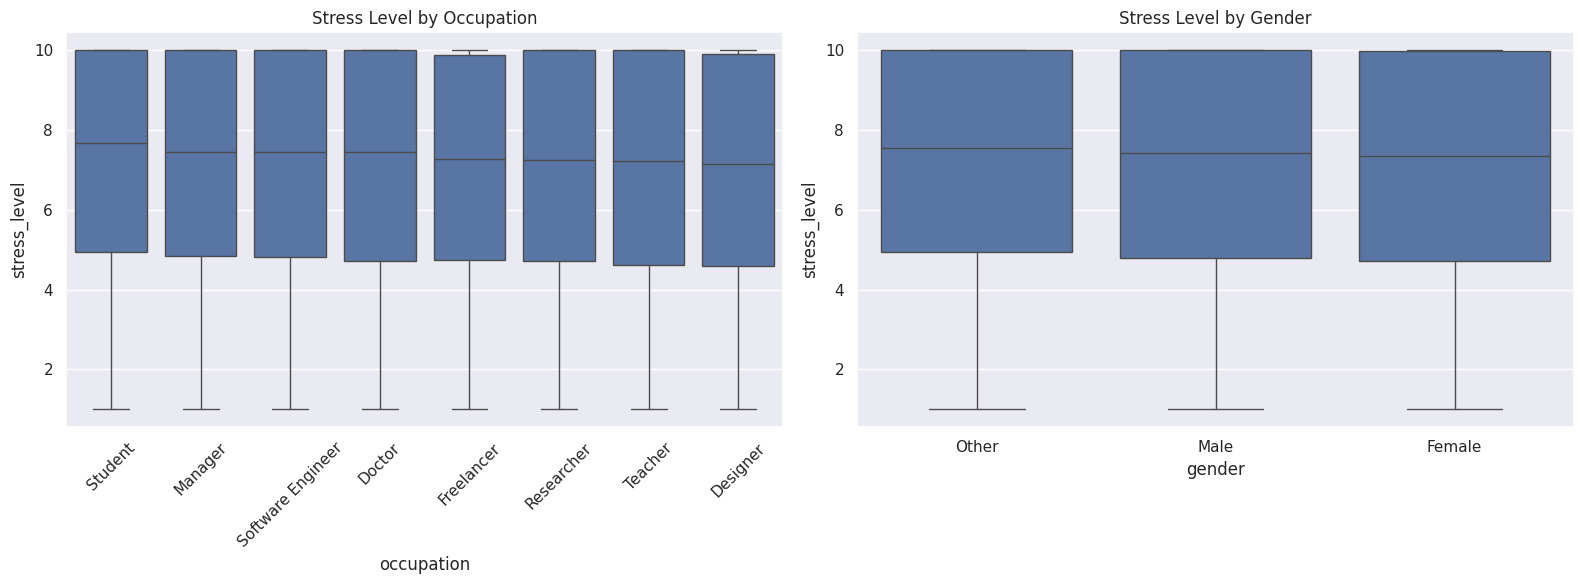

Mean stress by occupation:
occupation
Student              7.18
Manager              7.06
Software Engineer    7.02
Doctor               6.97
Researcher           6.92
Freelancer           6.90
Teacher              6.90
Designer             6.87

Mean stress by gender:
gender
Other     7.10
Male      7.00
Female    6.95


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

occ_order = df.groupby('occupation')['stress_level'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='occupation', y='stress_level', order=occ_order, ax=axes[0])
axes[0].set_title('Stress Level by Occupation')
axes[0].tick_params(axis='x', rotation=45)

gender_order = df.groupby('gender')['stress_level'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='gender', y='stress_level', order=gender_order, ax=axes[1])
axes[1].set_title('Stress Level by Gender')

plt.tight_layout()
plt.show()

print('Mean stress by occupation:')
print(df.groupby('occupation')['stress_level'].mean().sort_values(ascending=False).round(2).to_string())
print('\nMean stress by gender:')
print(df.groupby('gender')['stress_level'].mean().sort_values(ascending=False).round(2).to_string())

### 7. Correlation Matrix

Categorical columns are label-encoded (for correlation purposes only) before computing Pearson correlations.

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder() 
corr = pd.DataFrame()
for col in df.columns: 
        corr[col] = le.fit_transform(df[col])

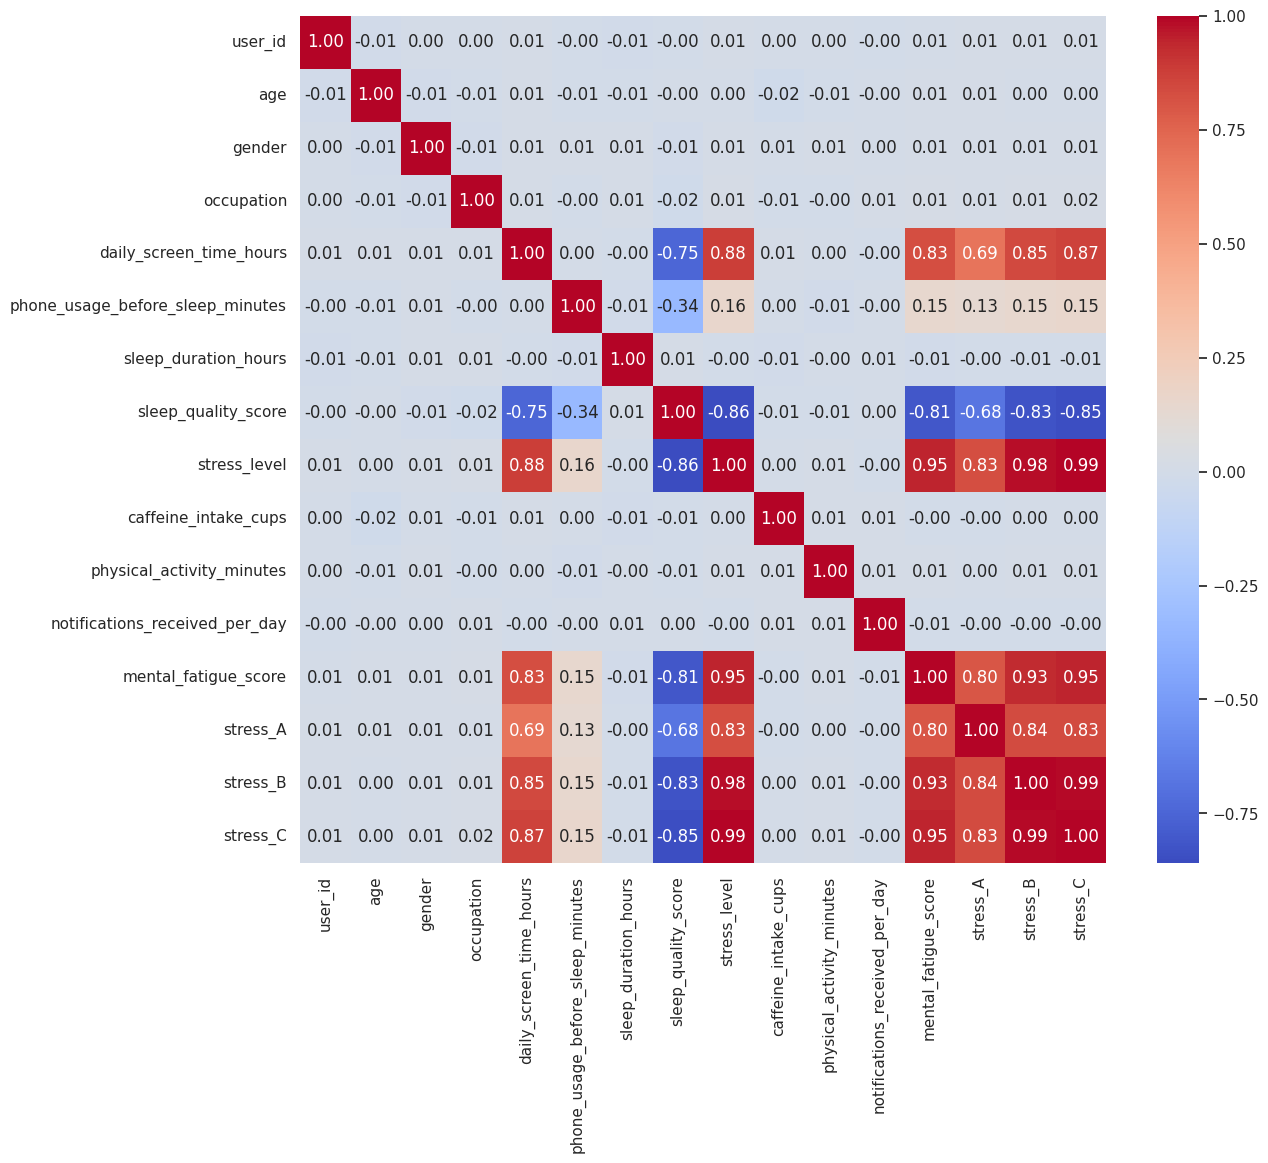

In [10]:
plt.figure(figsize=(13, 11))
correlation_matrix = corr.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

## Preprocessing

In [11]:
from itertools import product

df_clean = df.copy()
df_clean = df_clean.drop(columns=['user_id'])

le_gender = LabelEncoder()
le_occ    = LabelEncoder()
df_clean['gender']     = le_gender.fit_transform(df_clean['gender'])
df_clean['occupation'] = le_occ.fit_transform(df_clean['occupation'])

feature_cols = [
    'age', 'gender', 'occupation', 'daily_screen_time_hours',
    'phone_usage_before_sleep_minutes', 'sleep_duration_hours',
    'sleep_quality_score', 'caffeine_intake_cups',
    'physical_activity_minutes', 'notifications_received_per_day',
    'mental_fatigue_score'
]

X_raw = df_clean[feature_cols].copy()
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=feature_cols)

y_A = df_clean['stress_A'].reset_index(drop=True)
y_B = df_clean['stress_B'].reset_index(drop=True)
y_C = df_clean['stress_C'].reset_index(drop=True)

C_values = [0.001, 0.01, 0.1, 1, 10, 100]

mlp_configs = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50), (100, 100), (200,), (150, 100), (100, 100, 50)],
    'learning_rate_init': [0.001, 0.005, 0.01],
    'activation':         ['logistic', 'relu'],
}

print('X shape:', X_scaled.shape)
print('Scenario A classes:', y_A.value_counts().sort_index().to_dict())
print('Scenario B classes:', y_B.value_counts().sort_index().to_dict())
print('Scenario C classes:', y_C.value_counts().sort_index().to_dict())
print('MLP grid size:', len(mlp_configs['hidden_layer_sizes']) * len(mlp_configs['learning_rate_init']) * len(mlp_configs['activation']), 'configs')


X shape: (15000, 11)
Scenario A classes: {0: 4106, 1: 10894}
Scenario B classes: {0: 1380, 1: 2132, 2: 2561, 3: 2545, 4: 6382}
Scenario C classes: {0: 661, 1: 719, 2: 985, 3: 1147, 4: 1290, 5: 1271, 6: 1325, 7: 1220, 8: 1330, 9: 5052}
MLP grid size: 48 configs


In [12]:
def evaluate(model, X_train, y_train, X_test, y_test, label=""):
    cv_f1s = []
    kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    for _ in range(5):
        for tr_idx, val_idx in kf.split(X_train, y_train):
            model.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
            preds = model.predict(X_train.iloc[val_idx])
            cv_f1s.append(f1_score(y_train.iloc[val_idx], preds, average='macro', zero_division=0))
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    test_f1  = f1_score(y_test, y_pred, average='macro', zero_division=0)
    print(label)
    print(f"CV  F1  : {np.mean(cv_f1s):.4f} +/- {np.std(cv_f1s):.4f}")
    print(f"Test acc: {test_acc:.4f}")
    print(f"Test F1 : {test_f1:.4f}")
    print(classification_report(y_test, y_pred, zero_division=0))
    fig, ax = plt.subplots(figsize=(6, 4))
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(ax=ax, colorbar=False)
    ax.set_title(label)
    plt.tight_layout()
    plt.show()
    return float(np.mean(cv_f1s)), float(np.std(cv_f1s)), float(test_f1), float(test_acc)


# SVM train and evaluate Function

In [ ]:

def train_evaluate_svm(X, y, scenario_name, kernel='rbf', C=1.0,
                        n_splits=5, test_size=0.2, random_state=42):
    """
    Train an SVM classifier and report cross-val + test-set metrics.
    Applies RandomOverSampler only when there are >= 2 classes in the split.
    """
    from collections import Counter
    from imblearn.over_sampling import SMOTE


    # Drop NaN rows that qcut may introduce
    mask = y.notna()
    X_ = X[mask].reset_index(drop=True)   
    y_ = y[mask].reset_index(drop=True)   

    class_counts = Counter(y_)
    valid_classes = {cls for cls, cnt in class_counts.items() if cnt >= 2}
    valid_mask = y_.isin(valid_classes)
    X_ = X_[valid_mask].reset_index(drop=True)
    y_ = y_[valid_mask].reset_index(drop=True)

    n_classes = y_.nunique()
    if n_classes < 2:
        print(f'[SKIP] {scenario_name}: only {n_classes} class(es) found — cannot train.')
        return None

    print(f'\n{"="*65}')
    print(f'  {scenario_name}')
    print(f'  kernel={kernel}  C={C}  classes={sorted(y_.unique())}')
    print(f'{"="*65}')

    #Train / test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_, y_, test_size=test_size, stratify=y_, random_state=random_state)

    #  Oversampling (training set only) 
    # Only oversample if every class has >= 1 sample in training
    min_samples = min(Counter(y_train).values())
    if min_samples >= 1 and y_train.nunique() >= 2:
        smote = SMOTE(random_state=random_state, k_neighbors=3)  
        X_res, y_res = smote.fit_resample(X_train, y_train)
        print('  [INFO] SMOTE utilizado.')
    else:
        X_res, y_res = X_train, y_train
        print('  [INFO] Oversampling skipped (not enough samples per class).')

    # Reduce folds if dataset too small
    actual_splits = min(n_splits, int(min(Counter(y_res).values())))
    actual_splits = max(actual_splits, 2)
    skf = StratifiedKFold(n_splits=actual_splits, shuffle=True,
                          random_state=random_state)
    svm_cv = SVC(kernel=kernel, C=C, random_state=random_state)
    cv_scores = cross_val_score(svm_cv, X_res, y_res,
                                cv=skf, scoring='accuracy')
    print(f'Cross-val accuracy ({actual_splits}-fold): '
          f'{cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

    svm_final = SVC(kernel=kernel, C=C, random_state=random_state)
    svm_final.fit(X_res, y_res)

    y_pred = svm_final.predict(X_test)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print(f'\nTest-set results:')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Precision: {prec:.4f}  (weighted)')
    print(f'  Recall   : {rec:.4f}  (weighted)')
    print(f'  F1-Score : {f1:.4f}  (weighted)')
    print(f'\nClassification Report:\n')
    print(classification_report(y_test, y_pred, zero_division=0))

    # Confusion matrix 
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, ax=ax, colorbar=False,
        cmap='Blues', normalize='true')
    ax.set_title(f'Confusion Matrix - {scenario_name}', fontsize=13)
    plt.tight_layout()
    plt.show()

    return {'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(),
            'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1,'y_test': y_test.tolist(),'y_pred':    y_pred.tolist(),
            }


## Scenario A — Binary Classification (2 classes)

In [14]:
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_scaled, y_A, test_size=0.2, random_state=42)
print("Train:", X_train_A.shape, "| Test:", X_test_A.shape)
print("Train class dist:", y_train_A.value_counts().sort_index().to_dict())

Train: (12000, 11) | Test: (3000, 11)
Train class dist: {0: 3300, 1: 8700}


### Base (No Resampling)

#### SVM


  Scenario A - Binary (no stress vs stress)
  kernel=rbf  C=2  classes=[np.int64(0), np.int64(1)]
  [INFO] SMOTE utilizado.
Cross-val accuracy (5-fold): 0.9563 ± 0.0031

Test-set results:
  Accuracy : 0.9377
  Precision: 0.9410  (weighted)
  Recall   : 0.9377  (weighted)
  F1-Score : 0.9385  (weighted)

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.94      0.89       821
           1       0.97      0.94      0.96      2179

    accuracy                           0.94      3000
   macro avg       0.91      0.94      0.92      3000
weighted avg       0.94      0.94      0.94      3000



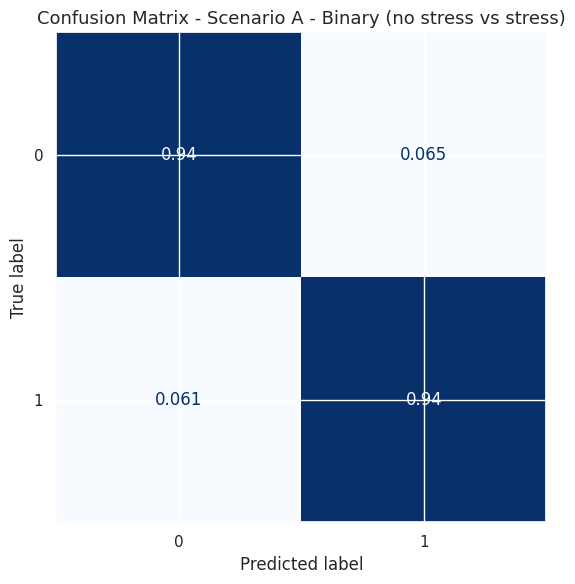

In [15]:
results_A_svm = train_evaluate_svm(
    X_scaled, y_A,
    scenario_name='Scenario A - Binary (no stress vs stress)',
    kernel='rbf',
    C=2,
    random_state=20
)

#### Naive Bayes

A | Base | Naive Bayes
CV  F1  : 0.9220 +/- 0.0024
Test acc: 0.9333
Test F1 : 0.9191
              precision    recall  f1-score   support

           0       0.82      0.96      0.89       806
           1       0.98      0.93      0.95      2194

    accuracy                           0.93      3000
   macro avg       0.90      0.94      0.92      3000
weighted avg       0.94      0.93      0.93      3000



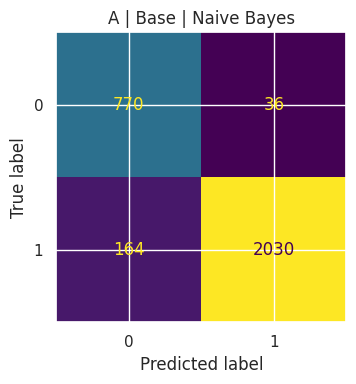

In [17]:
nb_A = GaussianNB()
res_nb_A_base = evaluate(nb_A, X_train_A, y_train_A, X_test_A, y_test_A,
                         label="A | Base | Naive Bayes")

#### MLP — Parameter Tuning

In [18]:
mlp_results_A = []
for hl, lr, act in product(mlp_configs['hidden_layer_sizes'],
                            mlp_configs['learning_rate_init'],
                            mlp_configs['activation']):
    mlp = MLPClassifier(hidden_layer_sizes=hl, learning_rate_init=lr,
                        activation=act, max_iter=2000, early_stopping=True, n_iter_no_change=15, validation_fraction=0.1, random_state=1)
    mlp.fit(X_train_A, y_train_A)
    f1 = f1_score(y_test_A, mlp.predict(X_test_A), average='macro', zero_division=0)
    mlp_results_A.append({'hidden': str(hl), 'lr': lr, 'act': act, 'f1': f1})

mlp_df_A = pd.DataFrame(mlp_results_A).sort_values('f1', ascending=False)
display(mlp_df_A.head(10))
best_mlp_A_cfg = mlp_df_A.iloc[0]
print(f"Best: hidden={best_mlp_A_cfg['hidden']}  lr={best_mlp_A_cfg['lr']}  act={best_mlp_A_cfg['act']}")


,hidden,lr,act,f1
8,"(100,)",0.005,logistic,0.937222
42,"(100, 100, 50)",0.001,logistic,0.936232
32,"(200,)",0.005,logistic,0.935983
2,"(50,)",0.005,logistic,0.935387
6,"(100,)",0.001,logistic,0.935287
38,"(150, 100)",0.005,logistic,0.934838
35,"(200,)",0.010,relu,0.934492
28,"(100, 100)",0.010,logistic,0.934449
30,"(200,)",0.001,logistic,0.934235
12,"(50, 50)",0.001,logistic,0.934218


Best: hidden=(100,)  lr=0.005  act=logistic


A | Base | MLP (best config)
CV  F1  : 0.9280 +/- 0.0009
Test acc: 0.9503
Test F1 : 0.9372
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       806
           1       0.97      0.96      0.97      2194

    accuracy                           0.95      3000
   macro avg       0.93      0.94      0.94      3000
weighted avg       0.95      0.95      0.95      3000



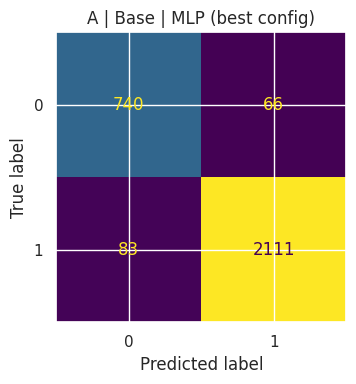

In [19]:
import ast
best_mlp_A = MLPClassifier(
    hidden_layer_sizes=ast.literal_eval(best_mlp_A_cfg['hidden']),
    learning_rate_init=best_mlp_A_cfg['lr'],
    activation=best_mlp_A_cfg['act'],
    max_iter=2000, early_stopping=True, n_iter_no_change=15, validation_fraction=0.1, random_state=1)
res_mlp_A_base = evaluate(best_mlp_A, X_train_A, y_train_A, X_test_A, y_test_A,
                           label="A | Base | MLP (best config)")

### OverSampling

In [20]:
over_A = RandomOverSampler(random_state=42)
X_over_A_np, y_over_A_np = over_A.fit_resample(X_train_A, y_train_A)
X_over_A = pd.DataFrame(X_over_A_np, columns=feature_cols)
y_over_A = pd.Series(y_over_A_np)
print("After oversampling:", X_over_A.shape)
print("Class dist:", y_over_A.value_counts().sort_index().to_dict())

After oversampling: (17400, 11)
Class dist: {0: 8700, 1: 8700}


#### Naive Bayes

A | OverSampling | Naive Bayes
CV  F1  : 0.9384 +/- 0.0029
Test acc: 0.9233
Test F1 : 0.9089
              precision    recall  f1-score   support

           0       0.79      0.98      0.87       806
           1       0.99      0.90      0.95      2194

    accuracy                           0.92      3000
   macro avg       0.89      0.94      0.91      3000
weighted avg       0.94      0.92      0.93      3000



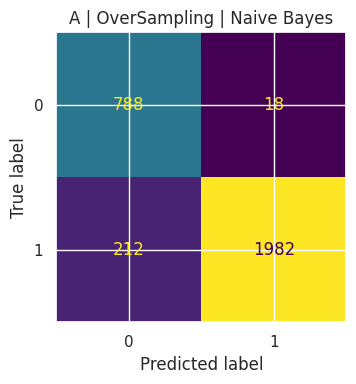

In [21]:
nb_A_ov = GaussianNB()
res_nb_A_over = evaluate(nb_A_ov, X_over_A, y_over_A, X_test_A, y_test_A,
                         label="A | OverSampling | Naive Bayes")

#### MLP

A | OverSampling | MLP
CV  F1  : 0.9487 +/- 0.0044
Test acc: 0.9387
Test F1 : 0.9251
              precision    recall  f1-score   support

           0       0.84      0.95      0.89       806
           1       0.98      0.93      0.96      2194

    accuracy                           0.94      3000
   macro avg       0.91      0.94      0.93      3000
weighted avg       0.94      0.94      0.94      3000



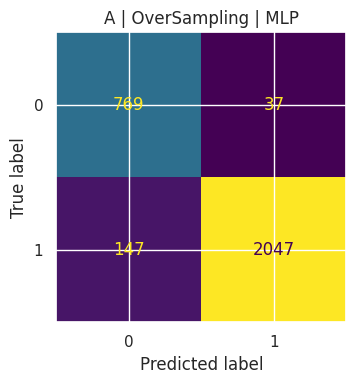

In [22]:
mlp_A_ov = MLPClassifier(
    hidden_layer_sizes=ast.literal_eval(best_mlp_A_cfg['hidden']),
    learning_rate_init=best_mlp_A_cfg['lr'],
    activation=best_mlp_A_cfg['act'],
    max_iter=2000, random_state=1)
res_mlp_A_over = evaluate(mlp_A_ov, X_over_A, y_over_A, X_test_A, y_test_A,
                           label="A | OverSampling | MLP")


### UnderSampling

In [23]:
under_A = RandomUnderSampler(random_state=42)
X_under_A_np, y_under_A_np = under_A.fit_resample(X_train_A, y_train_A)
X_under_A = pd.DataFrame(X_under_A_np, columns=feature_cols)
y_under_A = pd.Series(y_under_A_np)
print("After undersampling:", X_under_A.shape)
print("Class dist:", y_under_A.value_counts().sort_index().to_dict())

After undersampling: (6600, 11)
Class dist: {0: 3300, 1: 3300}


#### Naive Bayes

A | UnderSampling | Naive Bayes
CV  F1  : 0.9405 +/- 0.0029
Test acc: 0.9240
Test F1 : 0.9096
              precision    recall  f1-score   support

           0       0.79      0.98      0.87       806
           1       0.99      0.90      0.95      2194

    accuracy                           0.92      3000
   macro avg       0.89      0.94      0.91      3000
weighted avg       0.94      0.92      0.93      3000



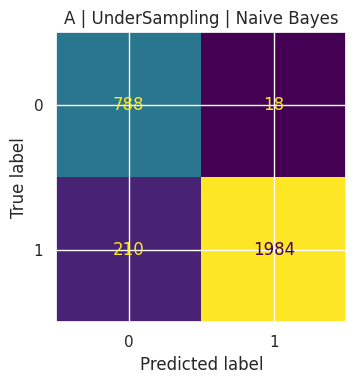

In [24]:
nb_A_un = GaussianNB()
res_nb_A_under = evaluate(nb_A_un, X_under_A, y_under_A, X_test_A, y_test_A,
                          label="A | UnderSampling | Naive Bayes")

#### MLP

A | UnderSampling | MLP
CV  F1  : 0.9425 +/- 0.0038
Test acc: 0.9383
Test F1 : 0.9249
              precision    recall  f1-score   support

           0       0.84      0.96      0.89       806
           1       0.98      0.93      0.96      2194

    accuracy                           0.94      3000
   macro avg       0.91      0.94      0.92      3000
weighted avg       0.94      0.94      0.94      3000



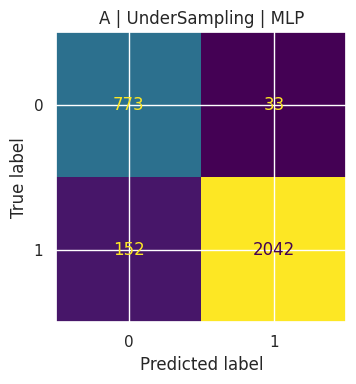

In [25]:
mlp_A_un = MLPClassifier(
    hidden_layer_sizes=ast.literal_eval(best_mlp_A_cfg['hidden']),
    learning_rate_init=best_mlp_A_cfg['lr'],
    activation=best_mlp_A_cfg['act'],
    max_iter=2000, early_stopping=True, n_iter_no_change=15, validation_fraction=0.1, random_state=1)
res_mlp_A_under = evaluate(mlp_A_un, X_under_A, y_under_A, X_test_A, y_test_A,
                            label="A | UnderSampling | MLP")

### Scenario A — Results Summary

In [26]:
results_A = pd.DataFrame([
    {'Strategy': 'Base',          'Model': 'Naive Bayes', 'CV_f1': res_nb_A_base[0],   'CV_std': res_nb_A_base[1],   'Test_f1': res_nb_A_base[2],   'Test_acc': res_nb_A_base[3]},
    {'Strategy': 'Base',          'Model': 'MLP',         'CV_f1': res_mlp_A_base[0],  'CV_std': res_mlp_A_base[1],  'Test_f1': res_mlp_A_base[2],  'Test_acc': res_mlp_A_base[3]},
    {'Strategy': 'Base',          'Model': 'SVM',         'CV_f1': results_A_svm['cv_mean'], 'CV_std': results_A_svm['cv_std'], 'Test_f1': results_A_svm['f1'], 'Test_acc': results_A_svm['accuracy']},
    {'Strategy': 'OverSampling',  'Model': 'Naive Bayes', 'CV_f1': res_nb_A_over[0],   'CV_std': res_nb_A_over[1],   'Test_f1': res_nb_A_over[2],   'Test_acc': res_nb_A_over[3]},
    {'Strategy': 'OverSampling',  'Model': 'MLP',         'CV_f1': res_mlp_A_over[0],  'CV_std': res_mlp_A_over[1],  'Test_f1': res_mlp_A_over[2],  'Test_acc': res_mlp_A_over[3]},
    {'Strategy': 'UnderSampling', 'Model': 'Naive Bayes', 'CV_f1': res_nb_A_under[0],  'CV_std': res_nb_A_under[1],  'Test_f1': res_nb_A_under[2],  'Test_acc': res_nb_A_under[3]},
    {'Strategy': 'UnderSampling', 'Model': 'MLP',         'CV_f1': res_mlp_A_under[0], 'CV_std': res_mlp_A_under[1], 'Test_f1': res_mlp_A_under[2], 'Test_acc': res_mlp_A_under[3]},
]).round(4)
display(results_A)


,Strategy,Model,CV_f1,CV_std,Test_f1,Test_acc
0,Base,Naive Bayes,0.9220,0.0024,0.9191,0.9333
1,Base,MLP,0.9280,0.0009,0.9372,0.9503
2,Base,SVM,0.9563,0.0031,0.9385,0.9377
3,OverSampling,Naive Bayes,0.9384,0.0029,0.9089,0.9233
4,OverSampling,MLP,0.9487,0.0044,0.9251,0.9387
5,UnderSampling,Naive Bayes,0.9405,0.0029,0.9096,0.9240
6,UnderSampling,MLP,0.9425,0.0038,0.9249,0.9383


## Scenario B — 5-Class Classification

The models classifies stress into five levels: **no stress** (0), **low** (1), **moderate** (2), **high** (3), **extreme** (4).

In [23]:
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_scaled, y_B, test_size=0.2, random_state=42)
print("Train:", X_train_B.shape, "| Test:", X_test_B.shape)
print("Train class dist:", y_train_B.value_counts().sort_index().to_dict())

Train: (12000, 11) | Test: (3000, 11)
Train class dist: {0: 1097, 1: 1720, 2: 2053, 3: 2012, 4: 5118}


### Base (No Resampling)

#### SVM


  Scenario B - 5-Class (no stress / low / moderate / high / extreme)
  kernel=rbf  C=10  classes=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  [INFO] SMOTE utilizado.
Cross-val accuracy (5-fold): 0.8728 ± 0.0059

Test-set results:
  Accuracy : 0.7600
  Precision: 0.7664  (weighted)
  Recall   : 0.7600  (weighted)
  F1-Score : 0.7625  (weighted)

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.76      0.74       276
           1       0.62      0.62      0.62       427
           2       0.64      0.62      0.63       512
           3       0.61      0.69      0.64       509
           4       0.94      0.89      0.92      1276

    accuracy                           0.76      3000
   macro avg       0.71      0.72      0.71      3000
weighted avg       0.77      0.76      0.76      3000



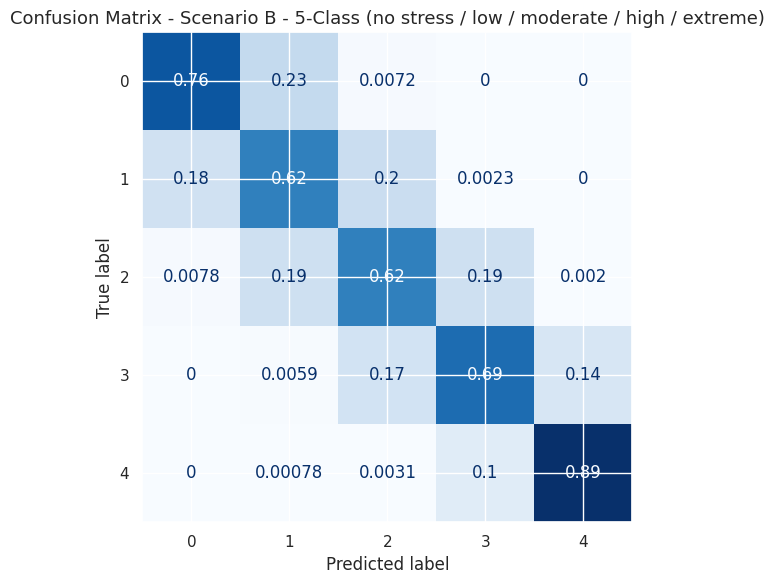

In [19]:
results_B_svm = train_evaluate_svm(
    X_scaled, y_B,
    scenario_name='Scenario B - 5-Class (no stress / low / moderate / high / extreme)',
    kernel='rbf',
    C=10
)

#### Verificar a quanto de distancia o modelo classificou mal os elementos 

Total de previsões: 3000
Total de erros: 720
Distribuição dos erros: {-3: 1, -2: 11, -1: 385, 1: 319, 2: 4}


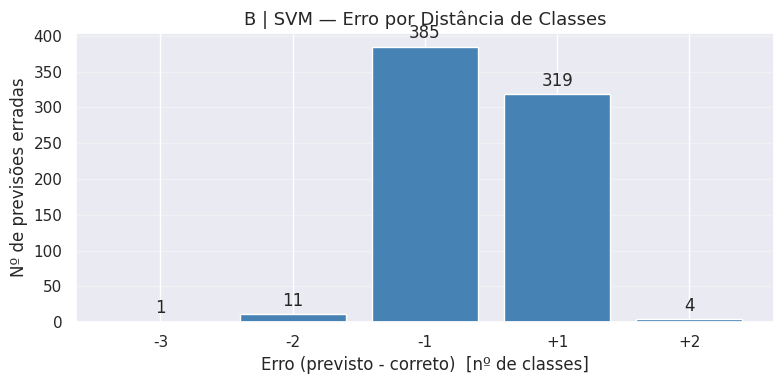

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

y_true = np.array(results_B_svm['y_test'])
y_pred = np.array(results_B_svm['y_pred'])

mask = y_true != y_pred
erros = y_pred[mask].astype(int) - y_true[mask].astype(int)

print(f"Total de previsões: {len(y_true)}")
print(f"Total de erros: {mask.sum()}")
print(f"Distribuição dos erros: {dict(sorted(Counter(erros.tolist()).items()))}")

c = Counter(erros.tolist())
dists = sorted(c.keys())
counts = [c[d] for d in dists]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar([f'{d:+d}' for d in dists], counts, color='steelblue', edgecolor='white')
ax.bar_label(bars, padding=3)
ax.set_title('B | SVM — Erro por Distância de Classes', fontsize=13)
ax.set_xlabel('Erro (previsto - correto)  [nº de classes]')
ax.set_ylabel('Nº de previsões erradas')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### Naive Bayes

B | Base | Naive Bayes
CV  F1  : 0.7535 +/- 0.0106
Test acc: 0.8107
Test F1 : 0.7732
              precision    recall  f1-score   support

           0       0.84      0.81      0.82       283
           1       0.68      0.72      0.70       412
           2       0.70      0.70      0.70       508
           3       0.70      0.72      0.71       533
           4       0.94      0.92      0.93      1264

    accuracy                           0.81      3000
   macro avg       0.77      0.77      0.77      3000
weighted avg       0.81      0.81      0.81      3000



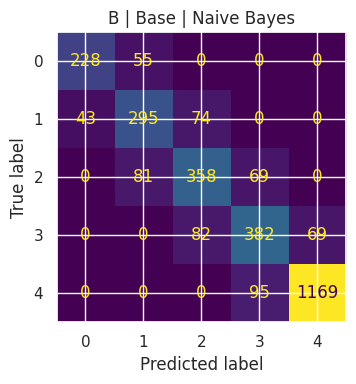

In [24]:
nb_B = GaussianNB()
res_nb_B_base = evaluate(nb_B, X_train_B, y_train_B, X_test_B, y_test_B,
                         label="B | Base | Naive Bayes")

#### MLP — Parameter Tuning

In [30]:
mlp_results_B = []
for hl, lr, act in product(mlp_configs['hidden_layer_sizes'],
                            mlp_configs['learning_rate_init'],
                            mlp_configs['activation']):
    mlp = MLPClassifier(hidden_layer_sizes=hl, learning_rate_init=lr,
                        activation=act, max_iter=2000, early_stopping=True, n_iter_no_change=15, validation_fraction=0.1, random_state=1)
    mlp.fit(X_train_B, y_train_B)
    f1 = f1_score(y_test_B, mlp.predict(X_test_B), average='macro', zero_division=0)
    mlp_results_B.append({'hidden': str(hl), 'lr': lr, 'act': act, 'f1': f1})

mlp_df_B = pd.DataFrame(mlp_results_B).sort_values('f1', ascending=False)
display(mlp_df_B.head(10))
best_mlp_B_cfg = mlp_df_B.iloc[0]
print(f"Best: hidden={best_mlp_B_cfg['hidden']}  lr={best_mlp_B_cfg['lr']}  act={best_mlp_B_cfg['act']}")


,hidden,lr,act,f1
40,"(150, 100)",0.010,logistic,0.773662
18,"(100, 50)",0.001,logistic,0.773016
44,"(100, 100, 50)",0.005,logistic,0.771957
14,"(50, 50)",0.005,logistic,0.770591
0,"(50,)",0.001,logistic,0.769088
12,"(50, 50)",0.001,logistic,0.769032
6,"(100,)",0.001,logistic,0.766416
2,"(50,)",0.005,logistic,0.766195
20,"(100, 50)",0.005,logistic,0.765668
42,"(100, 100, 50)",0.001,logistic,0.765389


Best: hidden=(150, 100)  lr=0.01  act=logistic


B | Base | MLP (best config)
CV  F1  : 0.7533 +/- 0.0172
Test acc: 0.8120
Test F1 : 0.7737
              precision    recall  f1-score   support

           0       0.84      0.83      0.83       283
           1       0.68      0.77      0.72       412
           2       0.70      0.69      0.69       508
           3       0.73      0.64      0.68       533
           4       0.93      0.94      0.94      1264

    accuracy                           0.81      3000
   macro avg       0.77      0.78      0.77      3000
weighted avg       0.81      0.81      0.81      3000



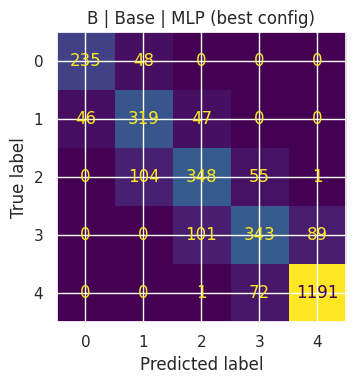

In [31]:
best_mlp_B = MLPClassifier(
    hidden_layer_sizes=ast.literal_eval(best_mlp_B_cfg['hidden']),
    learning_rate_init=best_mlp_B_cfg['lr'],
    activation=best_mlp_B_cfg['act'],
    max_iter=2000, early_stopping=True, n_iter_no_change=15, validation_fraction=0.1, random_state=1)
res_mlp_B_base = evaluate(best_mlp_B, X_train_B, y_train_B, X_test_B, y_test_B,
                           label="B | Base | MLP (best config)")

### OverSampling

In [32]:
over_B = RandomOverSampler(random_state=42)
X_over_B_np, y_over_B_np = over_B.fit_resample(X_train_B, y_train_B)
X_over_B = pd.DataFrame(X_over_B_np, columns=feature_cols)
y_over_B = pd.Series(y_over_B_np)
print("After oversampling:", X_over_B.shape)
print("Class dist:", y_over_B.value_counts().sort_index().to_dict())

After oversampling: (25590, 11)
Class dist: {0: 5118, 1: 5118, 2: 5118, 3: 5118, 4: 5118}


#### Naive Bayes

B | OverSampling | Naive Bayes
CV  F1  : 0.7609 +/- 0.0019
Test acc: 0.8020
Test F1 : 0.7698
              precision    recall  f1-score   support

           0       0.81      0.84      0.83       283
           1       0.69      0.70      0.70       412
           2       0.71      0.69      0.70       508
           3       0.65      0.77      0.71       533
           4       0.96      0.88      0.92      1264

    accuracy                           0.80      3000
   macro avg       0.76      0.78      0.77      3000
weighted avg       0.81      0.80      0.81      3000



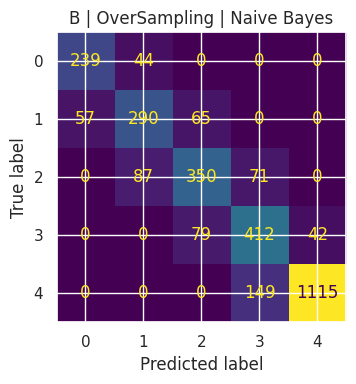

In [33]:
nb_B_ov = GaussianNB()
res_nb_B_over = evaluate(nb_B_ov, X_over_B, y_over_B, X_test_B, y_test_B,
                         label="B | OverSampling | Naive Bayes")

#### MLP

B | OverSampling | MLP
CV  F1  : 0.9280 +/- 0.0017
Test acc: 0.7443
Test F1 : 0.6910
              precision    recall  f1-score   support

           0       0.77      0.72      0.74       283
           1       0.58      0.61      0.59       412
           2       0.61      0.60      0.61       508
           3       0.61      0.61      0.61       533
           4       0.91      0.91      0.91      1264

    accuracy                           0.74      3000
   macro avg       0.69      0.69      0.69      3000
weighted avg       0.75      0.74      0.74      3000



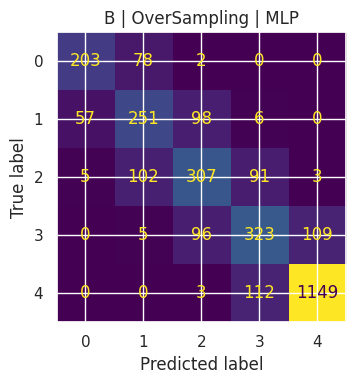

In [34]:
mlp_B_ov = MLPClassifier(
    hidden_layer_sizes=ast.literal_eval(best_mlp_B_cfg['hidden']),
    learning_rate_init=best_mlp_B_cfg['lr'],
    activation=best_mlp_B_cfg['act'],
    max_iter=2000, random_state=1)
res_mlp_B_over = evaluate(mlp_B_ov, X_over_B, y_over_B, X_test_B, y_test_B,
                           label="B | OverSampling | MLP")


### UnderSampling

In [35]:
under_B = RandomUnderSampler(random_state=42)
X_under_B_np, y_under_B_np = under_B.fit_resample(X_train_B, y_train_B)
X_under_B = pd.DataFrame(X_under_B_np, columns=feature_cols)
y_under_B = pd.Series(y_under_B_np)
print("After undersampling:", X_under_B.shape)
print("Class dist:", y_under_B.value_counts().sort_index().to_dict())

After undersampling: (5485, 11)
Class dist: {0: 1097, 1: 1097, 2: 1097, 3: 1097, 4: 1097}


#### Naive Bayes

B | UnderSampling | Naive Bayes
CV  F1  : 0.7568 +/- 0.0089
Test acc: 0.8007
Test F1 : 0.7677
              precision    recall  f1-score   support

           0       0.81      0.84      0.82       283
           1       0.68      0.70      0.69       412
           2       0.71      0.68      0.69       508
           3       0.65      0.77      0.71       533
           4       0.96      0.88      0.92      1264

    accuracy                           0.80      3000
   macro avg       0.76      0.78      0.77      3000
weighted avg       0.81      0.80      0.80      3000



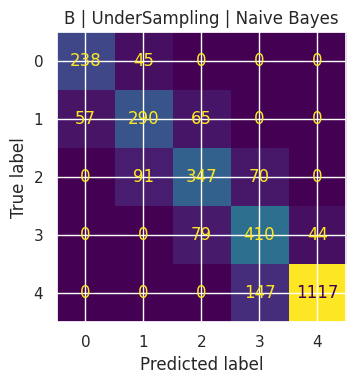

In [36]:
nb_B_un = GaussianNB()
res_nb_B_under = evaluate(nb_B_un, X_under_B, y_under_B, X_test_B, y_test_B,
                          label="B | UnderSampling | Naive Bayes")

#### MLP

B | UnderSampling | MLP
CV  F1  : 0.7517 +/- 0.0087
Test acc: 0.7977
Test F1 : 0.7573
              precision    recall  f1-score   support

           0       0.79      0.86      0.82       283
           1       0.63      0.75      0.69       412
           2       0.73      0.56      0.64       508
           3       0.67      0.76      0.71       533
           4       0.95      0.91      0.93      1264

    accuracy                           0.80      3000
   macro avg       0.75      0.77      0.76      3000
weighted avg       0.80      0.80      0.80      3000



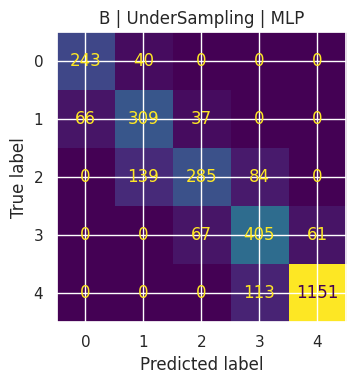

In [37]:
mlp_B_un = MLPClassifier(
    hidden_layer_sizes=ast.literal_eval(best_mlp_B_cfg['hidden']),
    learning_rate_init=best_mlp_B_cfg['lr'],
    activation=best_mlp_B_cfg['act'],
    max_iter=2000, early_stopping=True, n_iter_no_change=15, validation_fraction=0.1, random_state=1)
res_mlp_B_under = evaluate(mlp_B_un, X_under_B, y_under_B, X_test_B, y_test_B,
                            label="B | UnderSampling | MLP")

### Scenario B — Results Summary

In [38]:
results_B = pd.DataFrame([
    {'Strategy': 'Base',          'Model': 'Naive Bayes', 'CV_f1': res_nb_B_base[0],   'CV_std': res_nb_B_base[1],   'Test_f1': res_nb_B_base[2],   'Test_acc': res_nb_B_base[3]},
    {'Strategy': 'Base',          'Model': 'MLP',         'CV_f1': res_mlp_B_base[0],  'CV_std': res_mlp_B_base[1],  'Test_f1': res_mlp_B_base[2],  'Test_acc': res_mlp_B_base[3]},
    {'Strategy': 'Base',          'Model': 'SVM',         'CV_f1': results_B_svm['cv_mean'], 'CV_std': results_B_svm['cv_std'], 'Test_f1': results_B_svm['f1'], 'Test_acc': results_B_svm['accuracy']},
    {'Strategy': 'OverSampling',  'Model': 'Naive Bayes', 'CV_f1': res_nb_B_over[0],   'CV_std': res_nb_B_over[1],   'Test_f1': res_nb_B_over[2],   'Test_acc': res_nb_B_over[3]},
    {'Strategy': 'OverSampling',  'Model': 'MLP',         'CV_f1': res_mlp_B_over[0],  'CV_std': res_mlp_B_over[1],  'Test_f1': res_mlp_B_over[2],  'Test_acc': res_mlp_B_over[3]},
    {'Strategy': 'UnderSampling', 'Model': 'Naive Bayes', 'CV_f1': res_nb_B_under[0],  'CV_std': res_nb_B_under[1],  'Test_f1': res_nb_B_under[2],  'Test_acc': res_nb_B_under[3]},
    {'Strategy': 'UnderSampling', 'Model': 'MLP',         'CV_f1': res_mlp_B_under[0], 'CV_std': res_mlp_B_under[1], 'Test_f1': res_mlp_B_under[2], 'Test_acc': res_mlp_B_under[3]},
]).round(4)
display(results_B)


,Strategy,Model,CV_f1,CV_std,Test_f1,Test_acc
0,Base,Naive Bayes,0.7535,0.0106,0.7732,0.8107
1,Base,MLP,0.7533,0.0172,0.7737,0.8120
2,Base,SVM,0.8728,0.0059,0.7625,0.7600
3,OverSampling,Naive Bayes,0.7609,0.0019,0.7698,0.8020
4,OverSampling,MLP,0.9280,0.0017,0.6910,0.7443
5,UnderSampling,Naive Bayes,0.7568,0.0089,0.7677,0.8007
6,UnderSampling,MLP,0.7517,0.0087,0.7573,0.7977


## Scenario C — 10-Class Classification

The model classifies stress on a finer 10-level scale (0 = *no stress* … 9 = *maximum*). More classes make the problem harder;

In [39]:
X_train_C, X_test_C, y_train_C, y_test_C = train_test_split(
    X_scaled, y_C, test_size=0.2, random_state=42)
print("Train:", X_train_C.shape, "| Test:", X_test_C.shape)
print("Train class dist:", y_train_C.value_counts().sort_index().to_dict())

Train: (12000, 11) | Test: (3000, 11)
Train class dist: {0: 527, 1: 570, 2: 809, 3: 911, 4: 1033, 5: 1020, 6: 1036, 7: 976, 8: 1083, 9: 4035}


### Base (No Resampling)

#### SVM


  Scenario C - 10-Class (no stress → maximum)
  kernel=rbf  C=1  classes=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
  [INFO] SMOTE utilizado.
Cross-val accuracy (5-fold): 0.7061 ± 0.0044

Test-set results:
  Accuracy : 0.5800
  Precision: 0.5974  (weighted)
  Recall   : 0.5800  (weighted)
  F1-Score : 0.5865  (weighted)

Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.71      0.68       132
           1       0.35      0.34      0.34       144
           2       0.40      0.42      0.41       197
           3       0.38      0.39      0.39       229
           4       0.41      0.40      0.41       258
           5       0.41      0.39      0.40       254
           6       0.45      0.47      0.46       265
           7       0.43      0.38      0.40       244
           8       0.40      0.56      0.47       266
           9       0.94

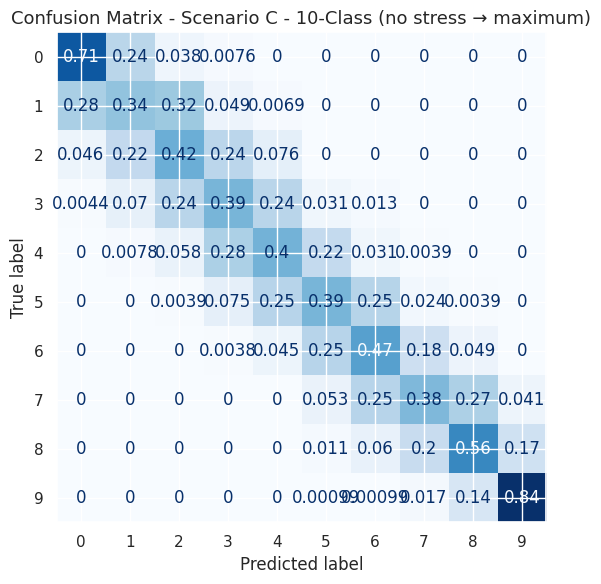

In [40]:
results_C_svm = train_evaluate_svm(
    X_scaled, y_C,
    scenario_name='Scenario C - 10-Class (no stress → maximum)',
    kernel='rbf',## poli , linear 
    C=1
)

#### Naive Bayes

C | Base | Naive Bayes
CV  F1  : 0.5055 +/- 0.0032
Test acc: 0.6120
Test F1 : 0.4998
              precision    recall  f1-score   support

           0       0.64      0.68      0.66       134
           1       0.45      0.35      0.39       149
           2       0.38      0.47      0.42       176
           3       0.43      0.38      0.40       236
           4       0.44      0.43      0.43       257
           5       0.44      0.47      0.46       251
           6       0.49      0.48      0.49       289
           7       0.42      0.34      0.37       244
           8       0.44      0.46      0.45       247
           9       0.91      0.94      0.92      1017

    accuracy                           0.61      3000
   macro avg       0.50      0.50      0.50      3000
weighted avg       0.61      0.61      0.61      3000



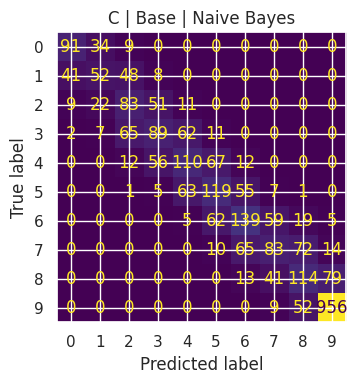

In [41]:
nb_C = GaussianNB()
res_nb_C_base = evaluate(nb_C, X_train_C, y_train_C, X_test_C, y_test_C,
                         label="C | Base | Naive Bayes")

#### MLP — Parameter Tuning

In [42]:
mlp_results_C = []
for hl, lr, act in product(mlp_configs['hidden_layer_sizes'],
                            mlp_configs['learning_rate_init'],
                            mlp_configs['activation']):
    mlp = MLPClassifier(hidden_layer_sizes=hl, learning_rate_init=lr,
                        activation=act, max_iter=2000, early_stopping=True, n_iter_no_change=15, validation_fraction=0.1, random_state=1)
    mlp.fit(X_train_C, y_train_C)
    f1 = f1_score(y_test_C, mlp.predict(X_test_C), average='macro', zero_division=0)
    mlp_results_C.append({'hidden': str(hl), 'lr': lr, 'act': act, 'f1': f1})

mlp_df_C = pd.DataFrame(mlp_results_C).sort_values('f1', ascending=False)
display(mlp_df_C.head(10))
best_mlp_C_cfg = mlp_df_C.iloc[0]
print(f"Best: hidden={best_mlp_C_cfg['hidden']}  lr={best_mlp_C_cfg['lr']}  act={best_mlp_C_cfg['act']}")


,hidden,lr,act,f1
20,"(100, 50)",0.005,logistic,0.513974
42,"(100, 100, 50)",0.001,logistic,0.510630
44,"(100, 100, 50)",0.005,logistic,0.508256
36,"(150, 100)",0.001,logistic,0.508180
46,"(100, 100, 50)",0.010,logistic,0.507662
30,"(200,)",0.001,logistic,0.506909
13,"(50, 50)",0.001,relu,0.506796
16,"(50, 50)",0.010,logistic,0.506154
24,"(100, 100)",0.001,logistic,0.506118
26,"(100, 100)",0.005,logistic,0.506049


Best: hidden=(100, 50)  lr=0.005  act=logistic


C | Base | MLP (best config)
CV  F1  : 0.5011 +/- 0.0044
Test acc: 0.6260
Test F1 : 0.5140
              precision    recall  f1-score   support

           0       0.65      0.75      0.69       134
           1       0.52      0.30      0.38       149
           2       0.38      0.56      0.45       176
           3       0.50      0.42      0.45       236
           4       0.46      0.46      0.46       257
           5       0.46      0.42      0.44       251
           6       0.50      0.47      0.48       289
           7       0.42      0.45      0.44       244
           8       0.48      0.37      0.42       247
           9       0.89      0.96      0.92      1017

    accuracy                           0.63      3000
   macro avg       0.53      0.51      0.51      3000
weighted avg       0.62      0.63      0.62      3000



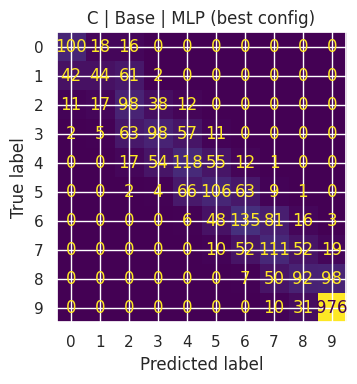

In [43]:
best_mlp_C = MLPClassifier(
    hidden_layer_sizes=ast.literal_eval(best_mlp_C_cfg['hidden']),
    learning_rate_init=best_mlp_C_cfg['lr'],
    activation=best_mlp_C_cfg['act'],
    max_iter=2000, early_stopping=True, n_iter_no_change=15, validation_fraction=0.1, random_state=1)
res_mlp_C_base = evaluate(best_mlp_C, X_train_C, y_train_C, X_test_C, y_test_C,
                           label="C | Base | MLP (best config)")

### OverSampling

In [44]:
over_C = SMOTE(random_state=42)
X_over_C_np, y_over_C_np = over_C.fit_resample(X_train_C, y_train_C)
X_over_C = pd.DataFrame(X_over_C_np, columns=feature_cols)
y_over_C = pd.Series(y_over_C_np)
print('After oversampling:', X_over_C.shape)
print('Class dist:', y_over_C.value_counts().sort_index().to_dict())


After oversampling: (40350, 11)
Class dist: {0: 4035, 1: 4035, 2: 4035, 3: 4035, 4: 4035, 5: 4035, 6: 4035, 7: 4035, 8: 4035, 9: 4035}


#### Naive Bayes

C | OverSampling | Naive Bayes
CV  F1  : 0.5786 +/- 0.0021
Test acc: 0.5953
Test F1 : 0.5060
              precision    recall  f1-score   support

           0       0.64      0.65      0.64       134
           1       0.45      0.45      0.45       149
           2       0.37      0.44      0.40       176
           3       0.44      0.39      0.41       236
           4       0.46      0.41      0.44       257
           5       0.44      0.49      0.46       251
           6       0.50      0.45      0.47       289
           7       0.42      0.42      0.42       244
           8       0.38      0.61      0.47       247
           9       0.95      0.84      0.89      1017

    accuracy                           0.60      3000
   macro avg       0.51      0.51      0.51      3000
weighted avg       0.62      0.60      0.60      3000



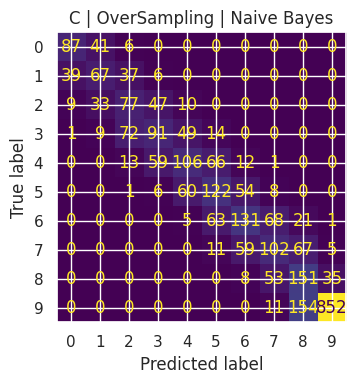

In [45]:
nb_C_ov = GaussianNB()
res_nb_C_over = evaluate(nb_C_ov, X_over_C, y_over_C, X_test_C, y_test_C,
                         label="C | OverSampling | Naive Bayes")

#### MLP

In [ ]:
mlp_C_ov = MLPClassifier(
    hidden_layer_sizes=ast.literal_eval(best_mlp_C_cfg['hidden']),
    learning_rate_init=best_mlp_C_cfg['lr'],
    activation=best_mlp_C_cfg['act'],
    max_iter=2000, random_state=1)
res_mlp_C_over = evaluate(mlp_C_ov, X_over_C, y_over_C, X_test_C, y_test_C,
                           label="C | OverSampling | MLP")

/media/rodrigo/7016FD4216FD0A3C/UC/3.2/AC/gaitamole/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:792: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


### UnderSampling

In [ ]:
under_C = RandomUnderSampler(random_state=42)
X_under_C_np, y_under_C_np = under_C.fit_resample(X_train_C, y_train_C)
X_under_C = pd.DataFrame(X_under_C_np, columns=feature_cols)
y_under_C = pd.Series(y_under_C_np)
print("After undersampling:", X_under_C.shape)
print("Class dist:", y_under_C.value_counts().sort_index().to_dict())

After undersampling: (5270, 11)
Class dist: {0: 527, 1: 527, 2: 527, 3: 527, 4: 527, 5: 527, 6: 527, 7: 527, 8: 527, 9: 527}


#### Naive Bayes

C | UnderSampling | Naive Bayes
CV  F1  : 0.5108 +/- 0.0156
Test acc: 0.6010
Test F1 : 0.5093
              precision    recall  f1-score   support

           0       0.63      0.69      0.66       134
           1       0.44      0.45      0.45       149
           2       0.35      0.40      0.37       176
           3       0.44      0.40      0.42       236
           4       0.48      0.39      0.43       257
           5       0.45      0.52      0.48       251
           6       0.50      0.46      0.48       289
           7       0.44      0.41      0.42       244
           8       0.39      0.61      0.48       247
           9       0.95      0.85      0.90      1017

    accuracy                           0.60      3000
   macro avg       0.51      0.52      0.51      3000
weighted avg       0.62      0.60      0.61      3000



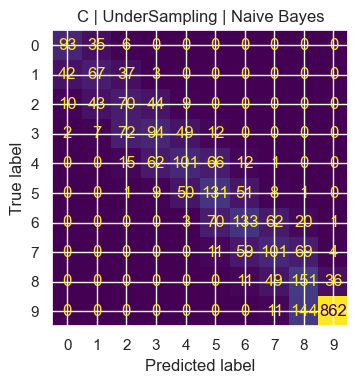

In [ ]:
nb_C_un = GaussianNB()
res_nb_C_under = evaluate(nb_C_un, X_under_C, y_under_C, X_test_C, y_test_C,
                          label="C | UnderSampling | Naive Bayes")

#### MLP

C | UnderSampling | MLP
CV  F1  : 0.5184 +/- 0.0115
Test acc: 0.6153
Test F1 : 0.5144
              precision    recall  f1-score   support

           0       0.57      0.81      0.67       134
           1       0.41      0.32      0.36       149
           2       0.42      0.40      0.41       176
           3       0.47      0.58      0.52       236
           4       0.48      0.40      0.44       257
           5       0.45      0.47      0.46       251
           6       0.51      0.43      0.47       289
           7       0.46      0.38      0.41       244
           8       0.41      0.63      0.50       247
           9       0.95      0.88      0.91      1017

    accuracy                           0.62      3000
   macro avg       0.51      0.53      0.51      3000
weighted avg       0.63      0.62      0.62      3000



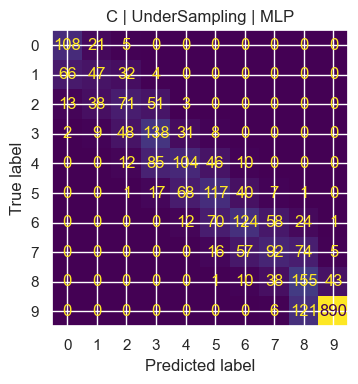

In [ ]:
mlp_C_un = MLPClassifier(
    hidden_layer_sizes=ast.literal_eval(best_mlp_C_cfg['hidden']),
    learning_rate_init=best_mlp_C_cfg['lr'],
    activation=best_mlp_C_cfg['act'],
    max_iter=2000, early_stopping=True, n_iter_no_change=15, validation_fraction=0.1, random_state=1)
res_mlp_C_under = evaluate(mlp_C_un, X_under_C, y_under_C, X_test_C, y_test_C,
                            label="C | UnderSampling | MLP")

### Scenario C — Results Summary

In [ ]:
results_C = pd.DataFrame([
    {'Strategy': 'Base',          'Model': 'Naive Bayes', 'CV_f1': res_nb_C_base[0],   'CV_std': res_nb_C_base[1],   'Test_f1': res_nb_C_base[2],   'Test_acc': res_nb_C_base[3]},
    {'Strategy': 'Base',          'Model': 'MLP',         'CV_f1': res_mlp_C_base[0],  'CV_std': res_mlp_C_base[1],  'Test_f1': res_mlp_C_base[2],  'Test_acc': res_mlp_C_base[3]},
    {'Strategy': 'Base',          'Model': 'SVM',         'CV_f1': results_C_svm['cv_mean'], 'CV_std': results_C_svm['cv_std'], 'Test_f1': results_C_svm['f1'], 'Test_acc': results_C_svm['accuracy']},
    {'Strategy': 'OverSampling',  'Model': 'Naive Bayes', 'CV_f1': res_nb_C_over[0],   'CV_std': res_nb_C_over[1],   'Test_f1': res_nb_C_over[2],   'Test_acc': res_nb_C_over[3]},
    {'Strategy': 'OverSampling',  'Model': 'MLP',         'CV_f1': res_mlp_C_over[0],  'CV_std': res_mlp_C_over[1],  'Test_f1': res_mlp_C_over[2],  'Test_acc': res_mlp_C_over[3]},
    {'Strategy': 'UnderSampling', 'Model': 'Naive Bayes', 'CV_f1': res_nb_C_under[0],  'CV_std': res_nb_C_under[1],  'Test_f1': res_nb_C_under[2],  'Test_acc': res_nb_C_under[3]},
    {'Strategy': 'UnderSampling', 'Model': 'MLP',         'CV_f1': res_mlp_C_under[0], 'CV_std': res_mlp_C_under[1], 'Test_f1': res_mlp_C_under[2], 'Test_acc': res_mlp_C_under[3]},
]).round(4)
display(results_C)


,Strategy,Model,CV_f1,CV_std,Test_f1,Test_acc
0,Base,SVM,0.7061,0.0044,0.5865,0.58


## Global Results Summary

In [ ]:
results_A['Scenario'] = 'A (binary)'
results_B['Scenario'] = 'B (5-class)'
results_C['Scenario'] = 'C (10-class)'
all_results = pd.concat([results_A, results_B, results_C], ignore_index=True)
all_results = all_results[['Scenario', 'Strategy', 'Model', 'CV_f1', 'CV_std', 'Test_f1', 'Test_acc']]
display(all_results.sort_values(['Scenario', 'Test_f1'], ascending=[True, False]).reset_index(drop=True))


,Scenario,Strategy,Model,CV_f1,CV_std,Test_f1,Test_acc
0,A (binary),Base,MLP,0.9280,0.0009,0.9372,0.9503
1,A (binary),OverSampling,MLP,0.9487,0.0044,0.9251,0.9387
2,A (binary),UnderSampling,MLP,0.9425,0.0038,0.9249,0.9383
3,A (binary),Base,Naive Bayes,0.9220,0.0024,0.9191,0.9333
4,A (binary),UnderSampling,Naive Bayes,0.9405,0.0029,0.9096,0.9240
5,A (binary),OverSampling,Naive Bayes,0.9384,0.0029,0.9089,0.9233
6,B (5-class),Base,MLP,0.7533,0.0172,0.7737,0.8120
7,B (5-class),Base,Naive Bayes,0.7535,0.0106,0.7732,0.8107
8,B (5-class),OverSampling,Naive Bayes,0.7609,0.0019,0.7698,0.8020
9,B (5-class),UnderSampling,Naive Bayes,0.7568,0.0089,0.7677,0.8007


In [ ]:
## ─── Análise de Erro por Distância de Classes ───────────────────────────────
# Para cada modelo e cenário multi-classe (B e C), calculamos a diferença
# entre a classe verdadeira e a classe prevista em cada erro.
# Ex: correto=3, previsto=5 → erro de +2 classes.

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter

# ── 1. Recolher previsões de todos os modelos ─────────────────────────────────
model_preds = {
    'B (5-class)': {},
    'C (10-class)': {},
}

for model_obj, name in [
    (nb_B,        'Base | Naive Bayes'),
    (best_mlp_B,  'Base | MLP'),
    (nb_B_ov,     'OverSampling | Naive Bayes'),
    (mlp_B_ov,    'OverSampling | MLP'),
    (nb_B_un,     'UnderSampling | Naive Bayes'),
    (mlp_B_un,    'UnderSampling | MLP'),
]:
    model_preds['B (5-class)'][name] = (np.array(y_test_B), model_obj.predict(X_test_B))

model_preds['B (5-class)']['Base | SVM'] = (
    np.array(results_B_svm['y_test']),
    np.array(results_B_svm['y_pred'])
)

for model_obj, name in [
    (nb_C,        'Base | Naive Bayes'),
    (best_mlp_C,  'Base | MLP'),
    (nb_C_ov,     'OverSampling | Naive Bayes'),
    (mlp_C_ov,    'OverSampling | MLP'),
    (nb_C_un,     'UnderSampling | Naive Bayes'),
    (mlp_C_un,    'UnderSampling | MLP'),
]:
    model_preds['C (10-class)'][name] = (np.array(y_test_C), model_obj.predict(X_test_C))

model_preds['C (10-class)']['Base | SVM'] = (
    np.array(results_C_svm['y_test']),
    np.array(results_C_svm['y_pred'])
)

# ── 2. Função auxiliar ────────────────────────────────────────────────────────
def get_error_distances(y_true, y_pred):
    """Devolve array com (pred − true) apenas onde houve erro."""
    mask = y_true != y_pred
    return (y_pred[mask].astype(int) - y_true[mask].astype(int))

# ── 3. Gráfico ────────────────────────────────────────────────────────────────
scenarios  = ['B (5-class)', 'C (10-class)']
palette    = plt.cm.tab10.colors

fig, axes = plt.subplots(len(scenarios), 1, figsize=(14, 6 * len(scenarios)),
                         constrained_layout=True)
fig.suptitle('Distribuição do Erro por Distância de Classes\n(apenas previsões erradas)',
             fontsize=15, fontweight='bold')

for ax, scenario in zip(axes, scenarios):
    models_in_scenario = model_preds[scenario]
    model_names = list(models_in_scenario.keys())

    dist_per_model = {}
    all_dists = set()
    for name, (y_true, y_pred) in models_in_scenario.items():
        c = Counter(get_error_distances(y_true, y_pred).tolist())
        dist_per_model[name] = c
        all_dists.update(c.keys())

    all_dists = sorted(all_dists)
    x = np.arange(len(all_dists))
    width = 0.8 / len(model_names)

    for i, name in enumerate(model_names):
        c = dist_per_model[name]
        heights = [c.get(d, 0) for d in all_dists]
        offset = (i - len(model_names) / 2 + 0.5) * width
        ax.bar(x + offset, heights, width=width, label=name,
               color=palette[i % len(palette)], edgecolor='white',
               linewidth=0.4, alpha=0.88)

    ax.set_title(f'Cenário {scenario}', fontsize=13)
    ax.set_xlabel('Erro (previsto − correto)  [nº de classes]', fontsize=11)
    ax.set_ylabel('Nº de previsões erradas', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{int(d):+d}' for d in all_dists])
    ax.legend(fontsize=8, ncol=2, loc='upper right')
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(axis='y', alpha=0.3)

plt.show()

# ── 4. Tabela-resumo ──────────────────────────────────────────────────────────
print("\n─── Resumo: distribuição de erros (magnitude absoluta) ───\n")
for scenario in scenarios:
    print(f"  Cenário {scenario}")
    print(f"  {'Modelo':<35} {'|erro|=1':>8} {'|erro|=2':>8} {'|erro|≥3':>9}  Total erros")
    print(f"  {'─'*75}")
    for name, (y_true, y_pred) in model_preds[scenario].items():
        dists = np.abs(get_error_distances(y_true, y_pred))
        total = len(dists)
        if total == 0:
            continue
        e1 = (dists == 1).sum()
        e2 = (dists == 2).sum()
        e3 = (dists >= 3).sum()
        print(f"  {name:<35} {e1/total*100:>7.1f}% {e2/total*100:>7.1f}% {e3/total*100:>8.1f}%  {total}")
    print()